# Assignment 4: Global Pollution Analysis and Energy Recovery

## Objective
Classify countries into **Low / Medium / High** pollution severity categories using pollution, energy, and environmental indicators.

This notebook covers:
1. Data preprocessing and feature engineering
2. Classification with Multinomial Naive Bayes, KNN, and Decision Tree
3. Model comparison, confusion matrices, and actionable insights


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)


In [2]:
# Update path if needed
DATA_PATH = 'Global_Pollution_Analysis.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
display(df.head())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

print('\nMissing values:')
display(df.isnull().sum().to_frame('missing_count'))


Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37



Data types:


,dtype
Country,str
Year,int64
Air_Pollution_Index,float64
Water_Pollution_Index,float64
Soil_Pollution_Index,float64
Industrial_Waste (in tons),float64
Energy_Recovered (in GWh),float64
CO2_Emissions (in MT),float64
Renewable_Energy (%),float64
Plastic_Waste_Produced (in tons),float64



Missing values:


,missing_count
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


## Phase 1: Data Preprocessing


In [3]:
work_df = df.copy()

# Clean column names for easier handling while keeping mapping transparent
work_df.columns = [c.strip() for c in work_df.columns]

# Identify key columns by name patterns (handles unit text in headers)
def find_col(cols, pattern):
    for c in cols:
        if pattern.lower() in c.lower():
            return c
    return None

air_col = find_col(work_df.columns, 'Air_Pollution_Index')
water_col = find_col(work_df.columns, 'Water_Pollution_Index')
soil_col = find_col(work_df.columns, 'Soil_Pollution_Index')
energy_recovered_col = find_col(work_df.columns, 'Energy_Recovered')
population_col = find_col(work_df.columns, 'Population')
year_col = find_col(work_df.columns, 'Year')
country_col = find_col(work_df.columns, 'Country')
energy_pc_col = find_col(work_df.columns, 'Energy_Consumption_Per_Capita')

required = [air_col, water_col, soil_col]
if any(c is None for c in required):
    raise ValueError('Required pollution index columns not found.')

# Split column types
categorical_cols = work_df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = work_df.select_dtypes(exclude=['object']).columns.tolist()

# Impute missing values
if numeric_cols:
    num_imp = SimpleImputer(strategy='median')
    work_df[numeric_cols] = num_imp.fit_transform(work_df[numeric_cols])
if categorical_cols:
    cat_imp = SimpleImputer(strategy='most_frequent')
    work_df[categorical_cols] = cat_imp.fit_transform(work_df[categorical_cols])

# Outlier handling for numeric features: IQR capping (winsorization)
for col in numeric_cols:
    q1 = work_df[col].quantile(0.25)
    q3 = work_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    work_df[col] = work_df[col].clip(lower=lower, upper=upper)

print('After imputation and outlier capping:')
display(work_df.head())


After imputation and outlier capping:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005.0,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001.0,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016.0,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018.0,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008.0,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [4]:
## Feature Engineering

# 1) Composite pollution score
work_df['Pollution_Score'] = work_df[[air_col, water_col, soil_col]].mean(axis=1)

# 2) Create 3-class target using tertiles of pollution score
q1 = work_df['Pollution_Score'].quantile(1/3)
q2 = work_df['Pollution_Score'].quantile(2/3)


def severity_label(score):
    if score <= q1:
        return 'Low'
    elif score <= q2:
        return 'Medium'
    return 'High'

work_df['Pollution_Severity'] = work_df['Pollution_Score'].apply(severity_label)

# 3) Energy recovered per capita (proxy)
if energy_recovered_col and population_col:
    # energy recovered in GWh per million population
    work_df['Energy_Recovered_Per_Capita_Proxy'] = work_df[energy_recovered_col] / (work_df[population_col] + 1e-9)

# 4) Yearly pollution trend per country (difference from previous year)
if country_col and year_col:
    trend_df = work_df[[country_col, year_col, 'Pollution_Score']].copy()
    trend_df[year_col] = pd.to_numeric(trend_df[year_col], errors='coerce')
    trend_df = trend_df.sort_values([country_col, year_col])
    trend_df['Pollution_Trend_Yearly'] = trend_df.groupby(country_col)['Pollution_Score'].diff()
    work_df = work_df.merge(
        trend_df[[country_col, year_col, 'Pollution_Trend_Yearly']],
        on=[country_col, year_col],
        how='left'
    )
    work_df['Pollution_Trend_Yearly'] = work_df['Pollution_Trend_Yearly'].fillna(0)

print('Class distribution:')
display(work_df['Pollution_Severity'].value_counts().to_frame('count'))

display(work_df.head())


Class distribution:


,count
Pollution_Severity,
Medium,68
High,67
Low,67


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Pollution_Score,Pollution_Severity,Energy_Recovered_Per_Capita_Proxy,Pollution_Trend_Yearly
0,Hungary,2005.0,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000,High,3.745618,0.000000
1,Singapore,2001.0,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333,Low,3.628707,0.000000
2,Romania,2016.0,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000,Low,3.932755,-16.083333
3,Cook Islands,2018.0,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667,High,2.141298,0.000000
4,Djibouti,2008.0,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667,High,0.216492,0.000000


In [11]:
# Prepare features and target
model_df = work_df.copy()

y = model_df['Pollution_Severity']
X = model_df.drop(columns=['Pollution_Severity'])

# Encode all object/string columns
label_encoders = {}

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'str' or X[col].dtype.name in ['string', 'object']:
        le = LabelEncoder()
        X[col] = pd.Series(le.fit_transform(X[col].astype(str)), index=X.index, dtype='int64')
        label_encoders[col] = le

print("X dtypes after encoding:")
print(X.dtypes)

# Encode target labels: Low, Medium, High
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print('\nTarget classes mapping:', dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

# Convert to numpy array to ensure all are numeric
X_numeric = X.astype('float64').values  

# Scale features to non-negative range for MultinomialNB compatibility
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

X dtypes after encoding:
Country                                     int64
Year                                      float64
Air_Pollution_Index                       float64
Water_Pollution_Index                     float64
Soil_Pollution_Index                      float64
Industrial_Waste (in tons)                float64
Energy_Recovered (in GWh)                 float64
CO2_Emissions (in MT)                     float64
Renewable_Energy (%)                      float64
Plastic_Waste_Produced (in tons)          float64
Energy_Consumption_Per_Capita (in MWh)    float64
Population (in millions)                  float64
GDP_Per_Capita (in USD)                   float64
Pollution_Score                           float64
Energy_Recovered_Per_Capita_Proxy         float64
Pollution_Trend_Yearly                    float64
dtype: object

Target classes mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Train shape: (161, 16) Test shape: (41, 16)


## Phase 2: Classification (Multinomial NB, KNN, Decision Tree)


In [12]:
def evaluate_model(name, model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f'\n{name} Classification Report:')
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Confusion_Matrix': cm
    }


In [13]:
class_names = list(target_encoder.classes_)

# 1) Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
result_nb = evaluate_model('Multinomial Naive Bayes', mnb, X_test, y_test, class_names)

# 2) KNN with hyperparameter tuning
knn = KNeighborsClassifier()
param_grid_knn = {'n_neighbors': list(range(3, 26, 2))}
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print('Best KNN params:', grid_knn.best_params_)
result_knn = evaluate_model('K-Nearest Neighbors', best_knn, X_test, y_test, class_names)

# 3) Decision Tree with pruning hyperparameters
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
print('Best Decision Tree params:', grid_dt.best_params_)
result_dt = evaluate_model('Decision Tree', best_dt, X_test, y_test, class_names)



Multinomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.57      0.62        14
         Low       0.75      0.69      0.72        13
      Medium       0.47      0.57      0.52        14

    accuracy                           0.61        41
   macro avg       0.63      0.61      0.62        41
weighted avg       0.63      0.61      0.61        41

Best KNN params: {'n_neighbors': 23}

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

        High       0.64      0.64      0.64        14
         Low       0.83      0.77      0.80        13
      Medium       0.47      0.50      0.48        14

    accuracy                           0.63        41
   macro avg       0.65      0.64      0.64        41
weighted avg       0.64      0.63      0.64        41

Best Decision Tree params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree Cla

## Phase 3: Reporting and Insights


In [14]:
results = [result_nb, result_knn, result_dt]

metrics_df = pd.DataFrame([{
    'Model': r['Model'],
    'Accuracy': r['Accuracy'],
    'Precision (Weighted)': r['Precision'],
    'Recall (Weighted)': r['Recall'],
    'F1-Score (Weighted)': r['F1-Score']
} for r in results]).sort_values(by='F1-Score (Weighted)', ascending=False)

display(metrics_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision (Weighted)': '{:.4f}',
    'Recall (Weighted)': '{:.4f}',
    'F1-Score (Weighted)': '{:.4f}'
}))


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
2,Decision Tree,0.9756,0.9772,0.9756,0.9756
1,K-Nearest Neighbors,0.6341,0.6431,0.6341,0.6380
0,Multinomial Naive Bayes,0.6098,0.6261,0.6098,0.6147


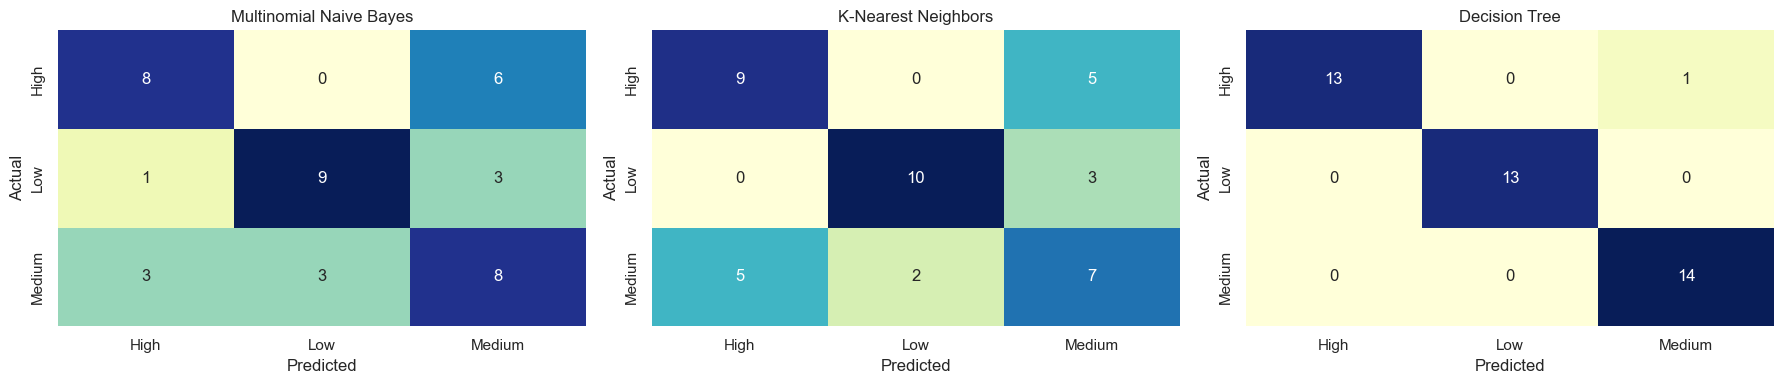

In [15]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, r in zip(axes, results):
    sns.heatmap(
        r['Confusion_Matrix'],
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        cbar=False,
        ax=ax,
        xticklabels=class_names,
        yticklabels=class_names
    )
    ax.set_title(r['Model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


,Feature,Importance
13,Pollution_Score,1.0
0,Country,0.0
1,Year,0.0
2,Air_Pollution_Index,0.0
3,Water_Pollution_Index,0.0
4,Soil_Pollution_Index,0.0
5,Industrial_Waste (in tons),0.0
6,Energy_Recovered (in GWh),0.0
7,CO2_Emissions (in MT),0.0
8,Renewable_Energy (%),0.0


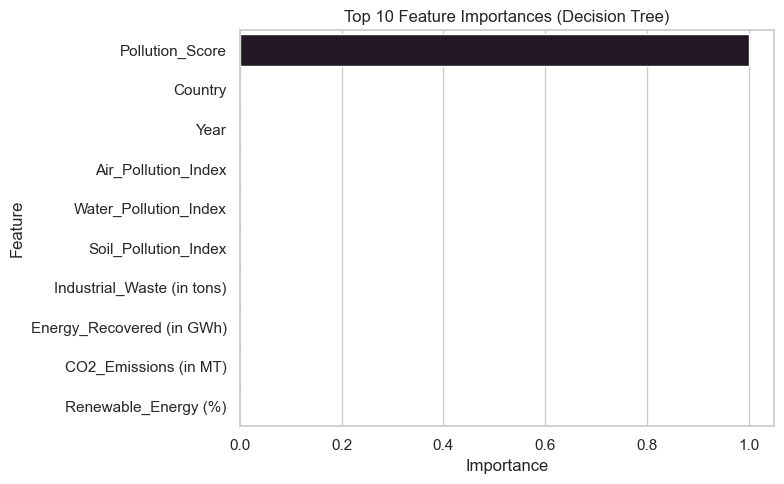

In [16]:
# Optional: feature importances from best decision tree
if hasattr(best_dt, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_dt.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    display(fi.head(15))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=fi.head(10), x='Importance', y='Feature', palette='mako')
    plt.title('Top 10 Feature Importances (Decision Tree)')
    plt.tight_layout()
    plt.show()
